<a href="https://colab.research.google.com/github/tmtngu/AITUAN7NHOM/blob/main/5_M%C3%B3n_%C4%82n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf

duong_dan="/content/drive/MyDrive/AI NHÓM TUẦN 7/5 Món Ăn/Train"
chieu_dai_anh,chieu_cao_anh=224,224
kich_thuoc_goi=32

train=tf.keras.utils.image_dataset_from_directory(
    duong_dan,
    labels='inferred',
    label_mode='categorical',
    image_size=(chieu_dai_anh,chieu_cao_anh),
    batch_size=kich_thuoc_goi,
    validation_split=0.2,
    subset='training',
    seed=123,
    crop_to_aspect_ratio=True)

ten_mon_an=train.class_names

test=tf.keras.utils.image_dataset_from_directory(
    duong_dan,
    labels='inferred',
    label_mode='categorical',
    image_size=(chieu_dai_anh,chieu_cao_anh),
    batch_size=kich_thuoc_goi,
    validation_split=0.2,
    subset='validation',
    seed=123,
    crop_to_aspect_ratio=True)

chuan_hoa=tf.keras.layers.Rescaling(1./255)
toi_uu=tf.data.AUTOTUNE

train=train.map(lambda x,y:(chuan_hoa(x),y)).cache().shuffle(1000).prefetch(buffer_size=toi_uu)
test=test.map(lambda x,y:(chuan_hoa(x),y)).cache().prefetch(buffer_size=toi_uu)

Found 1621 files belonging to 5 classes.
Using 1297 files for training.
Found 1621 files belonging to 5 classes.
Using 324 files for validation.


In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom
import matplotlib.pyplot as plt

so_mon_an=5
model=Sequential()

model.add(RandomFlip("horizontal",input_shape=(chieu_dai_anh,chieu_cao_anh,3)))
model.add(RandomRotation(0.2))
model.add(RandomZoom(0.2))

model.add(Conv2D(32,(3,3),activation='relu',padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64,(3,3),activation='relu',padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(128,(3,3),activation='relu',padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(256,(3,3),activation='relu',padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(so_mon_an, activation='softmax'))

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss="categorical_crossentropy",
              metrics=["accuracy"])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    12,845,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,236,933 (50.49 MB)

 Trainable params: 13,235,973 (50.49 MB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 363s 2s/step - accuracy: 0.4079 - loss: 2.3650 - val_accuracy: 0.2160 - val_loss: 4.0017
Epoch 2/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 5s 132ms/step - accuracy: 0.5289 - loss: 1.2664 - val_accuracy: 0.2160 - val_loss: 6.6173
Epoch 3/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 6s 136ms/step - accuracy: 0.5482 - loss: 1.2287 - val_accuracy: 0.2531 - val_loss: 7.2083
Epoch 4/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 5s 134ms/step - accuracy: 0.5775 - loss: 1.1451 - val_accuracy: 0.3272 - val_loss: 8.2872
Epoch 5/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 6s 138ms/step - accuracy: 0.5937 - loss: 1.0703 - val_accuracy: 0.2593 - val_loss: 9.9274
Epoch 6/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 6s 136ms/step - accuracy: 0.6060 - loss: 1.0513 - val_accuracy: 0.2685 - val_loss: 9.6657
Epoch 7/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 10s 139ms/step - accuracy: 0.6091 - loss: 1.0397 - val_accuracy: 0.2654 - val_loss: 8.1400
Epoch 8/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 6s 137ms/step - accuracy: 0.6469 - loss: 0.9870 - val_accuracy: 0.

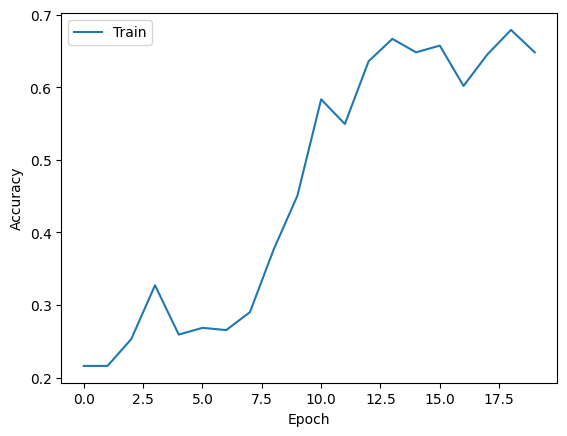

In [3]:
history=model.fit(
    train,
    epochs=20,
    validation_data=test)
plt.plot(history.history['val_accuracy'],label='ket qua')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train'], loc='upper left')
plt.show()
model.save("/content/filetrain5monantmt.h5")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step
Đây là món Bánh Xèo


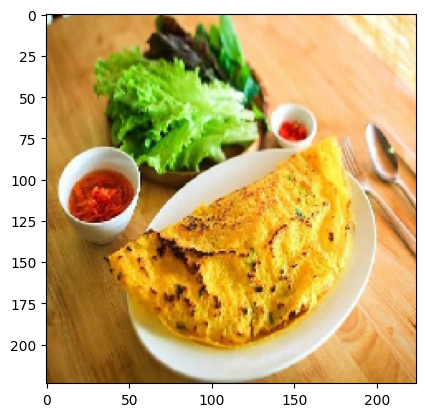

In [4]:
from keras.utils import load_img
import numpy as np
import matplotlib.pyplot as plt

path="/content/banh-xeo.jpg"
img=load_img(path,target_size=(chieu_dai_anh,chieu_cao_anh))
plt.imshow(img)
img=np.array(img)
img=img/255.0
img=img.reshape(1,chieu_dai_anh,chieu_cao_anh,3)

pred=np.argmax(model.predict(img))

ten = ten_mon_an[pred]
print(f"Đây là món {ten}")